# Comparación SFINCS vs HEC-RAS — Sensibilidad a la rugosidad de Manning

Caso de estudio: **Río Besaya — Corrales de Buelna**  

Compara la respuesta de dos modelos hidráulicos 2D ante la misma incertidumbre
en los coeficientes de Manning:

| Modelo | Ecuaciones | Ejecución |
|--------|-----------|----------|
| **SFINCS** | Inercial simplificada (sin términos advectivos) | GPU Docker / SLURM |
| **HEC-RAS 6.6** | Saint-Venant 2D completo | COM (rascontrol, Windows) |

**Nota**: Este notebook requiere haber ejecutado primero los notebooks 02 y 03
para disponer de los CSVs `sfincs_sensitivity_results.csv` y
`hecras_sensitivity_results.csv`, o puede cargar los datos directamente desde
los TIFFs usando `load_flood_ensemble`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from pyhydra.modeling.hydraulic.sensitivity import (
    load_flood_ensemble,
    build_manning_ensemble,
    flooded_area,
    spatial_stats,
    manning_flood_regression,
    filter_anomalous_simulations,
)

## Rutas

In [2]:
BASE_DIR         = Path("/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM")
SFINCS_DIR       = BASE_DIR / "Ejemplo_Besaya/corrales2/results"
HECRAS_DIR       = BASE_DIR / "HEC_RAS/results"
COMBINATIONS_DIR = BASE_DIR / "Ejemplo_Besaya/nsim_rugos"
MANNING_TIF      = BASE_DIR / "Ejemplo_Besaya/manning.tif"

CELL_AREA_M2 = 25.0
THRESHOLD    = 0.05

## 1 · Cargar ensembles de ambos modelos

In [3]:
flood_sf = load_flood_ensemble(str(SFINCS_DIR), threshold=THRESHOLD)
flood_hr = load_flood_ensemble(str(HECRAS_DIR), threshold=THRESHOLD)

# Simulations comunes a ambos modelos
common_sims = np.intersect1d(flood_sf.simulation.values, flood_hr.simulation.values)
flood_sf = flood_sf.sel(simulation=common_sims)
flood_hr = flood_hr.sel(simulation=common_sims)

print(f"SFINCS:  {flood_sf.shape}")
print(f"HEC-RAS: {flood_hr.shape}")
print(f"Simulaciones comunes: {len(common_sims)}")

SFINCS:  (1000, 1201, 679)
HEC-RAS: (1000, 1201, 679)
Simulaciones comunes: 1000


In [4]:
sim_numbers = common_sims.tolist()

manning = build_manning_ensemble(
    raster_path=str(MANNING_TIF),
    combinations_dir=str(COMBINATIONS_DIR),
    simulation_numbers=sim_numbers,
)

## 2 · Estadísticos por modelo

In [5]:
stats_sf = spatial_stats(flood_sf)
stats_hr = spatial_stats(flood_hr)
areas_sf = flooded_area(flood_sf, CELL_AREA_M2, THRESHOLD)
areas_hr = flooded_area(flood_hr, CELL_AREA_M2, THRESHOLD)

summary = pd.DataFrame({
    "SFINCS_calado_medio":   stats_sf["mean"].values,
    "HECRAS_calado_medio":   stats_hr["mean"].values,
    "SFINCS_area_km2":       areas_sf * 1e-6,
    "HECRAS_area_km2":       areas_hr * 1e-6,
}, index=common_sims)

summary.describe().round(3)

,SFINCS_calado_medio,HECRAS_calado_medio,SFINCS_area_km2,HECRAS_area_km2
count,1000.000,1000.000,1000.000,1000.000
mean,1.044,1.220,0.539,0.693
std,0.032,0.080,0.011,0.090
min,0.947,1.053,0.468,0.511
25%,1.024,1.152,0.532,0.665
50%,1.044,1.218,0.539,0.683
75%,1.065,1.297,0.547,0.716
max,1.135,1.930,0.565,2.187


In [6]:
# Build filter DataFrames from spatial stats already computed above
sf_filt_input = pd.DataFrame(
    {"depth_mean": stats_sf["mean"], "flooded_area_km2": areas_sf * 1e-6},
    index=common_sims,
)
hr_filt_input = pd.DataFrame(
    {"depth_mean": stats_hr["mean"], "flooded_area_km2": areas_hr * 1e-6},
    index=common_sims,
)

# z_threshold=5.0: captures only clear numerical non-convergence (area >1 km²
# or depth >1.7 m in HEC-RAS). The bimodal HEC-RAS area distribution is a
# real physical finding (two inundation regimes) and must NOT be removed.
flagged, report = filter_anomalous_simulations(
    sf_filt_input, hr_filt_input,
    metrics=["depth_mean", "flooded_area_km2"],
    z_threshold=5.0,
)

print(f"Simulaciones anómalas detectadas: {flagged.sum()}")
print(report.to_string())

# ── Apply filter ──────────────────────────────────────────────────────────────
valid_sims  = flagged[~flagged].index.values
flood_sf    = flood_sf.sel(simulation=valid_sims)
flood_hr    = flood_hr.sel(simulation=valid_sims)
manning     = manning.sel(simulation=valid_sims)
common_sims = valid_sims

# Recompute stats and areas on clean ensemble
stats_sf = spatial_stats(flood_sf)
stats_hr = spatial_stats(flood_hr)
areas_sf = flooded_area(flood_sf, CELL_AREA_M2, THRESHOLD)
areas_hr = flooded_area(flood_hr, CELL_AREA_M2, THRESHOLD)

print(f"\nSimulaciones válidas para el análisis: {len(common_sims)}")

Simulaciones anómalas detectadas: 5
            model            metric     value  robust_z
simulation                                             
633             0  flooded_area_km2  0.467650  6.843817
29              1        depth_mean  1.930207  6.696252
295             1        depth_mean  1.772342  5.212196
724             1        depth_mean  1.805451  5.523448
755             1        depth_mean  1.833522  5.787332



Simulaciones válidas para el análisis: 995


## 2b · Detección y eliminación de simulaciones anómalas

Se aplica un z-score robusto (MAD-normalizado) con umbral **k=5.0**.

- **k=5.0** elimina sólo no-convergencias numéricas evidentes (HEC-RAS área >1 km²,
  HEC-RAS calado >1.7 m). Son 5 simulaciones de 1.000 (0.5%).
- **k=3.0** se descartó porque la distribución de área de HEC-RAS es **bimodal**
  (dos regímenes de inundación físicamente distintos); aplicar k=3 eliminaría ambas
  colas de esa distribución bimodal, que es en sí un resultado científico relevante.
- **IQR 1.5×** también se descartó por el mismo motivo: eliminaría ~11% de sims.

## 3 · Distribuciones comparadas

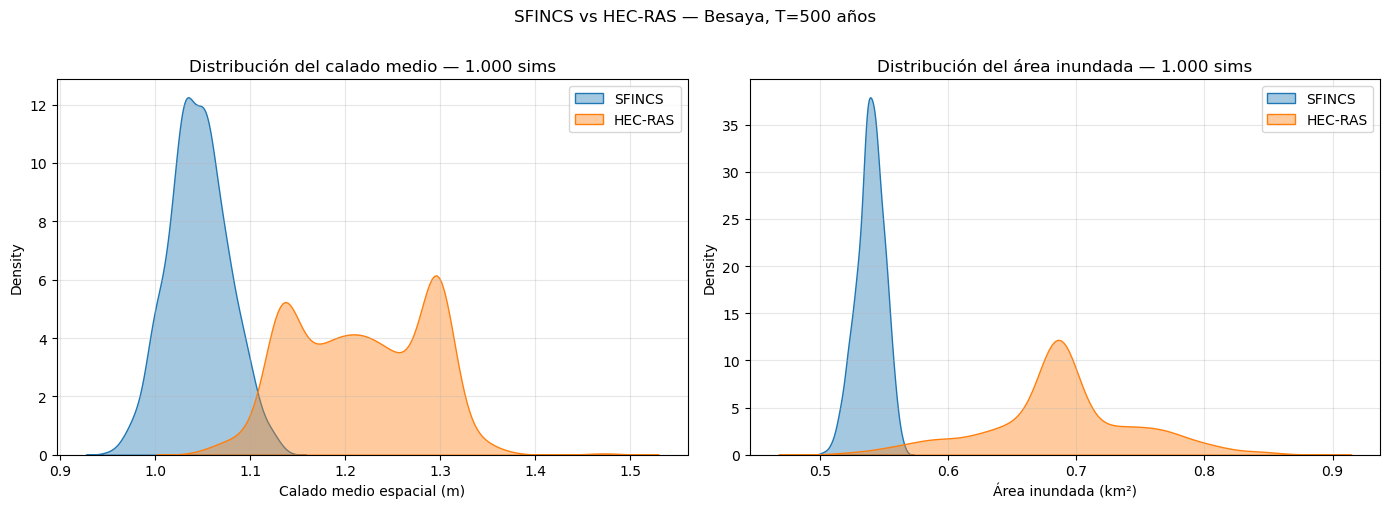

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.kdeplot(stats_sf["mean"], ax=ax, label="SFINCS", fill=True, alpha=0.4)
sns.kdeplot(stats_hr["mean"], ax=ax, label="HEC-RAS", fill=True, alpha=0.4)
ax.set_xlabel("Calado medio espacial (m)")
ax.set_title("Distribución del calado medio — 1.000 sims")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
sns.kdeplot(areas_sf * 1e-6, ax=ax, label="SFINCS", fill=True, alpha=0.4)
sns.kdeplot(areas_hr * 1e-6, ax=ax, label="HEC-RAS", fill=True, alpha=0.4)
ax.set_xlabel("Área inundada (km²)")
ax.set_title("Distribución del área inundada — 1.000 sims")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("SFINCS vs HEC-RAS — Besaya, T=500 años", y=1.01)
plt.tight_layout()
plt.show()

## 4 · Regresiones rugosidad ↔ calado: ambos modelos

In [8]:
reg_sf = manning_flood_regression(flood_sf, manning, CELL_AREA_M2, THRESHOLD)
reg_hr = manning_flood_regression(flood_hr, manning, CELL_AREA_M2, THRESHOLD)

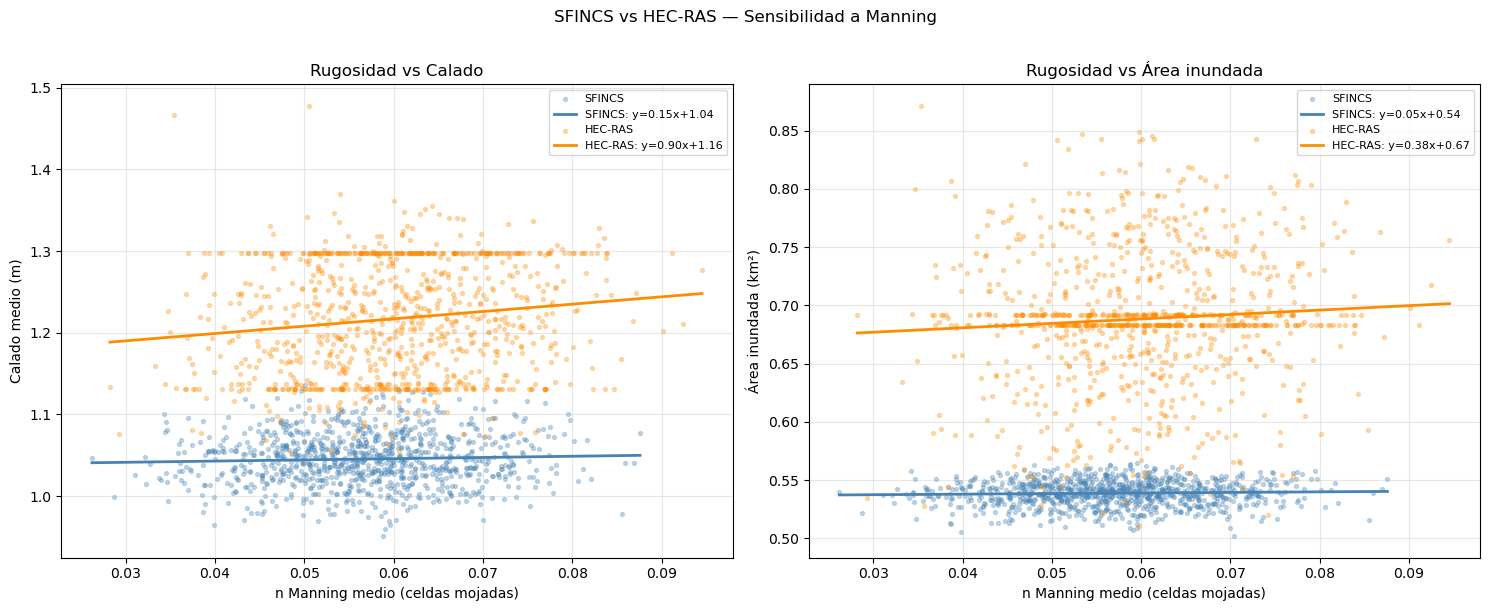

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, reg, label, color in [
    (axes[0], reg_sf, "SFINCS",  "steelblue"),
    (axes[0], reg_hr, "HEC-RAS", "darkorange"),
]:
    valid = reg[["manning_mean", "depth_mean"]].dropna()
    coef = np.polyfit(valid["manning_mean"], valid["depth_mean"], 1)
    x_line = np.linspace(valid["manning_mean"].min(), valid["manning_mean"].max(), 100)
    ax.scatter(valid["manning_mean"], valid["depth_mean"],
               alpha=0.3, s=8, color=color, label=label)
    ax.plot(x_line, np.polyval(coef, x_line), color=color, lw=2,
            label=f"{label}: y={coef[0]:.2f}x+{coef[1]:.2f}")

axes[0].set_xlabel("n Manning medio (celdas mojadas)")
axes[0].set_ylabel("Calado medio (m)")
axes[0].set_title("Rugosidad vs Calado")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for ax, reg, label, color in [
    (axes[1], reg_sf, "SFINCS",  "steelblue"),
    (axes[1], reg_hr, "HEC-RAS", "darkorange"),
]:
    valid = reg[["manning_mean", "flooded_area_m2"]].dropna()
    coef = np.polyfit(valid["manning_mean"], valid["flooded_area_m2"] * 1e-6, 1)
    x_line = np.linspace(valid["manning_mean"].min(), valid["manning_mean"].max(), 100)
    axes[1].scatter(valid["manning_mean"], valid["flooded_area_m2"] * 1e-6,
                    alpha=0.3, s=8, color=color, label=label)
    axes[1].plot(x_line, np.polyval(coef, x_line), color=color, lw=2,
                 label=f"{label}: y={coef[0]:.2f}x+{coef[1]:.2f}")

axes[1].set_xlabel("n Manning medio (celdas mojadas)")
axes[1].set_ylabel("Área inundada (km²)")
axes[1].set_title("Rugosidad vs Área inundada")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("SFINCS vs HEC-RAS — Sensibilidad a Manning", y=1.01)
plt.tight_layout()
plt.show()

## 5 · Coherencia entre modelos: calado sim-a-sim

In [10]:
# Alinear por simulation index para comparar directamente
df_comp = pd.DataFrame({
    "sfincs_depth":  stats_sf["mean"],
    "hecras_depth":  stats_hr["mean"],
    "sfincs_area":   areas_sf * 1e-6,
    "hecras_area":   areas_hr * 1e-6,
}, index=common_sims).dropna()

r_depth, p_depth = stats.pearsonr(df_comp["sfincs_depth"], df_comp["hecras_depth"])
r_area,  p_area  = stats.pearsonr(df_comp["sfincs_area"],  df_comp["hecras_area"])

print(f"Correlación calado:  r={r_depth:.3f}  (p={p_depth:.2e})")
print(f"Correlación área:    r={r_area:.3f}  (p={p_area:.2e})")

Correlación calado:  r=0.516  (p=6.74e-69)
Correlación área:    r=0.490  (p=3.28e-61)


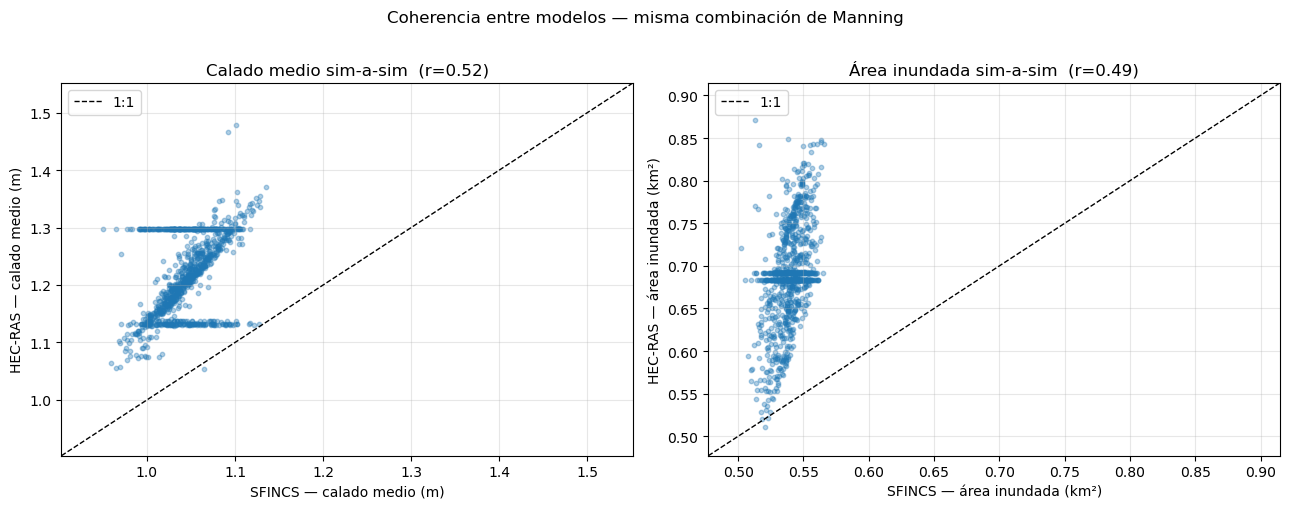

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df_comp["sfincs_depth"], df_comp["hecras_depth"], alpha=0.35, s=10)
lim = [df_comp[["sfincs_depth","hecras_depth"]].min().min() * 0.95,
       df_comp[["sfincs_depth","hecras_depth"]].max().max() * 1.05]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("SFINCS — calado medio (m)")
ax.set_ylabel("HEC-RAS — calado medio (m)")
ax.set_title(f"Calado medio sim-a-sim  (r={r_depth:.2f})")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(df_comp["sfincs_area"], df_comp["hecras_area"], alpha=0.35, s=10)
lim2 = [df_comp[["sfincs_area","hecras_area"]].min().min() * 0.95,
        df_comp[["sfincs_area","hecras_area"]].max().max() * 1.05]
ax.plot(lim2, lim2, "k--", lw=1, label="1:1")
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel("SFINCS — área inundada (km²)")
ax.set_ylabel("HEC-RAS — área inundada (km²)")
ax.set_title(f"Área inundada sim-a-sim  (r={r_area:.2f})")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Coherencia entre modelos — misma combinación de Manning", y=1.01)
plt.tight_layout()
plt.show()

## 6 · Coeficiente de variación: ¿qué modelo es más sensible a Manning?

In [12]:
def cv(series: pd.Series) -> float:
    """Coeficiente de variación en %."""
    return series.std() / series.mean() * 100

metrics = pd.DataFrame({
    "Métrica":  ["Calado medio (m)", "Área inundada (km²)"],
    "SFINCS_mean":  [stats_sf["mean"].mean(), (areas_sf * 1e-6).mean()],
    "SFINCS_std":   [stats_sf["mean"].std(),  (areas_sf * 1e-6).std()],
    "SFINCS_CV%":   [cv(stats_sf["mean"]),    cv(pd.Series(areas_sf * 1e-6))],
    "HECRAS_mean":  [stats_hr["mean"].mean(), (areas_hr * 1e-6).mean()],
    "HECRAS_std":   [stats_hr["mean"].std(),  (areas_hr * 1e-6).std()],
    "HECRAS_CV%":   [cv(stats_hr["mean"]),    cv(pd.Series(areas_hr * 1e-6))],
}).set_index("Métrica")

metrics.round(3)

,SFINCS_mean,SFINCS_std,SFINCS_CV%,HECRAS_mean,HECRAS_std,HECRAS_CV%
Métrica,,,,,,
Calado medio (m),1.045,0.032,3.015,1.217,0.069,5.692
Área inundada (km²),0.539,0.011,1.992,0.688,0.057,8.350


## 7 · Mapas de incertidumbre (desviación estándar espacial)

In [13]:
out = pd.DataFrame({
    "sfincs_depth_mean":   stats_sf["mean"],
    "sfincs_depth_median": stats_sf["median"],
    "sfincs_area_km2":     areas_sf * 1e-6,
    "sfincs_manning_mean": reg_sf["manning_mean"],
    "hecras_depth_mean":   stats_hr["mean"],
    "hecras_depth_median": stats_hr["median"],
    "hecras_area_km2":     areas_hr * 1e-6,
    "hecras_manning_mean": reg_hr["manning_mean"],
}, index=common_sims)

out.to_csv("comparison_sfincs_hecras_clean.csv")
print(f"Guardado: comparison_sfincs_hecras_clean.csv  ({len(out)} filas)")

# Export list of removed simulations for traceability
report.to_csv("anomalous_simulations.csv")
print(f"Guardado: anomalous_simulations.csv  ({len(report)} filas)")

Guardado: comparison_sfincs_hecras_clean.csv  (995 filas)
Guardado: anomalous_simulations.csv  (5 filas)


## 8 · Guardar resultados combinados

In [14]:
out = pd.DataFrame({
    "sfincs_depth_mean":   stats_sf["mean"],
    "sfincs_depth_median": stats_sf["median"],
    "sfincs_area_km2":     areas_sf * 1e-6,
    "sfincs_manning_mean": reg_sf["manning_mean"],
    "hecras_depth_mean":   stats_hr["mean"],
    "hecras_depth_median": stats_hr["median"],
    "hecras_area_km2":     areas_hr * 1e-6,
    "hecras_manning_mean": reg_hr["manning_mean"],
}, index=common_sims)

out.to_csv("comparison_sfincs_hecras.csv")
print(f"Guardado: comparison_sfincs_hecras.csv  ({len(out)} filas)")

Guardado: comparison_sfincs_hecras.csv  (995 filas)
